In [162]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [699]:
df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260914_185317_ejection_results.txt', header=None)

In [700]:
df.columns=['mass','time','result']

In [701]:
df

,mass,time,result
0,0.010000,0.000000,Captured
1,0.010000,0.000000,Captured
2,0.010000,0.000000,Captured
3,0.010000,1990.074380,Captured
4,0.010000,2985.111571,Captured
...,...,...,...
2549,0.000631,135957.115193,Ejected
2550,0.000631,135957.115193,Ejected
2551,0.000631,135957.115193,Ejected
2552,0.000631,137956.484534,Ejected


In [703]:
ejection_df, capture_df=compute_cumulative_outcome_fractions(df, df.mass.unique(),[800,800,800,800,800])

In [704]:
ejection_df.index

Index([              0.01, 0.0050118723362727, 0.0025118864315095,
       0.0012589254117941, 0.0006309573444801],
      dtype='float64')

In [705]:
masses=np.logspace(-2,-5,6)
t_maxes=2.02731513e+01*masses**(-2/3) + 6.97903308e+04

In [706]:
t_maxes

array([ 70227.10260437,  70887.45196906,  72546.17457829,  76712.69739405,
        87178.52952152, 113467.51123698])

In [707]:
ejection_df

,0.000000,999.371131,1990.074380,1995.006888,2985.111571,4998.423353,7980.027554,8955.334712,8988.717761,10972.537887,...,507680.534551,509679.276813,540659.781874,559647.833363,589628.967294,592627.080687,602620.791997,603620.163128,607617.647652,617611.358962
0.010000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375,0.78375
0.005012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875,0.74875
0.002512,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750,0.74750
0.001259,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.70375,0.70500,0.70625,0.70750,0.70875,0.71000,0.71125,0.71250,0.71375,0.71500
0.000631,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000


In [559]:
capture_df

,0.000000e+00,9.998419e+02,1.098621e+04,1.194045e+04,1.393052e+04,1.492556e+04,1.592060e+04,1.691563e+04,1.791067e+04,1.890571e+04,...,2.333631e+06,2.346629e+06,2.364626e+06,2.381623e+06,2.393622e+06,2.479608e+06,2.554596e+06,2.610587e+06,2.683576e+06,2.694574e+06
0.010000,0.00500,0.00500,0.00500,0.00625,0.00625,0.00625,0.00625,0.00625,0.00750,0.00750,...,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750
0.005012,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,...,0.02375,0.02375,0.02375,0.02375,0.02375,0.02375,0.02375,0.02375,0.02375,0.02375
0.002512,0.00250,0.00250,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,...,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875,0.00875
0.001259,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,...,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500
0.000631,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,...,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125
0.000316,0.00250,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,...,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750


In [560]:
np.logspace(-2,-3.5,6)

array([0.01      , 0.00501187, 0.00251189, 0.00125893, 0.00063096,
       0.00031623])

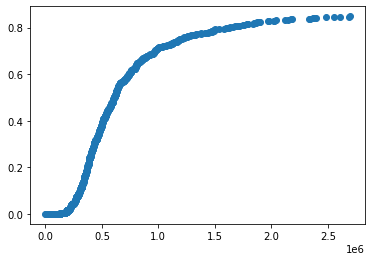

In [563]:
plt.scatter(ejection_df.columns,ejection_df.loc[ejection_df.index[-1]])
#plt.xlim(0,200_000)

(0.0, 200000.0)

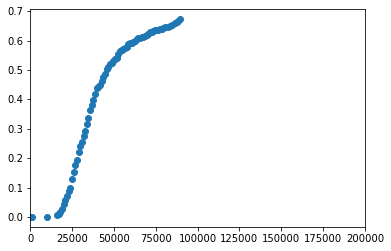

In [361]:
plt.scatter(ejection_df.columns,ejection_df.loc[ejection_df.index[0]])
plt.xlim(0,200_000)

In [278]:
e_scale=0.1
p=0.99
e_p=e_scale*np.sqrt(-2*np.log(1-p))
e_p

0.30348542587702926

In [260]:
t_scale=np.array([100_000,
100_000,
180_000,400_000,
1_000_000,
4_000_000])
masses=np.array([0.030027,
        0.0094955,
        0.00400422,
        0.00168856,
        0.00071206,
        0.00030027])

In [261]:
def mm_t_scaling(m, a,b):
    return a*m**(-3/2)+b

In [262]:
popt,pcov=curve_fit(mm_t_scaling,masses,t_scale)

In [287]:
masses=np.logspace(-2,-5,6)
t_maxes=2.02731513e+01*masses**(-3/2)+ 6.97903308e+04

In [288]:
t_maxes

array([9.00634821e+04, 2.30825696e+05, 1.34893970e+06, 1.02304349e+07,
       8.07786594e+07, 6.41163125e+08])

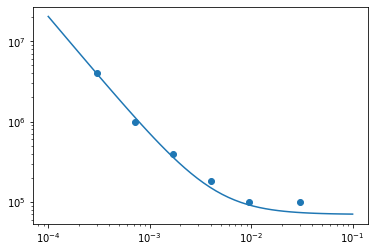

In [267]:
m=np.logspace(-4,-1)
plt.scatter(masses,t_scale)
plt.plot(m,mm_t_scaling(m,popt[0],popt[1]))
plt.xscale('log')
plt.yscale('log')

In [254]:
masses=np.logspace(-5,-2,6)


In [255]:
masses

array([1.00000000e-05, 3.98107171e-05, 1.58489319e-04, 6.30957344e-04,
       2.51188643e-03, 1.00000000e-02])

In [572]:
masses=np.logspace(-3.5,-2,6)

In [573]:
crit_e=2.1*masses**(1/4)

In [574]:
crit_e

array([0.2800395 , 0.33282757, 0.39556631, 0.47013144, 0.55875226,
       0.66407831])

In [575]:
e_scale=0.1
p=0.99
e_p=e_scale*np.sqrt(-2*np.log(1-p))
e_p

0.30348542587702926

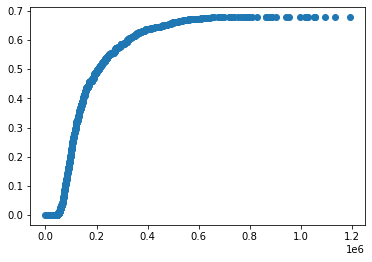

In [432]:
plt.scatter(ejection_df.columns,ejection_df.loc[ejection_df.index[-2]])
#plt.xlim(0,0.3e6)

In [585]:
files=[
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_0.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_1.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260914_185317_2.csv',

    


]

In [586]:
df=pd.DataFrame()
for file in files:
    temp_df=pd.read_csv(file)
    df=pd.concat([df,temp_df], ignore_index=True)

In [587]:
df

,m_planet,time,a,e
0,0.010000,231843.665319,0.507107417232181,0.079997
1,0.010000,231843.665319,0.5355925642547484,0.044146
2,0.010000,231842.670282,Unbound,10.323452
3,0.010000,231843.665319,0.6518782116167733,0.118985
4,0.010000,231843.665319,0.5321968760018114,0.362114
...,...,...,...,...
502,0.002512,370534.921053,0.7500800357775516,0.114366
503,0.002512,370534.921053,0.6155758599487909,0.217320
504,0.002512,370534.921053,0.6841873102171876,0.091921
505,0.002512,370534.921053,0.800248901089804,0.094051


In [588]:
bound_df.m_planet[1247]

KeyError: 1247

In [ ]:
bound_df=df[df.a != 'Unbound']

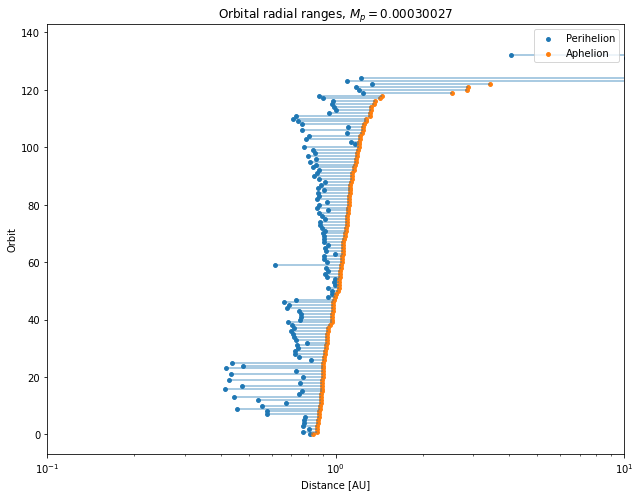

In [ ]:


# Make sure a and e are numeric
plot_df = bound_df.copy()

plot_df["a"] = pd.to_numeric(plot_df["a"], errors="coerce")
plot_df["e"] = pd.to_numeric(plot_df["e"], errors="coerce")

# Remove unbound / invalid rows
plot_df = plot_df.dropna(subset=["a", "e"])
plot_df = plot_df[(plot_df["Q"] < 50_000) & (plot_df["e"] < 1)]

# Perihelion and aphelion
plot_df["q"] = plot_df["a"] * (1 - plot_df["e"])
plot_df["Q"] = plot_df["a"] * (1 + plot_df["e"])

# Select one planet mass
mass = 0.00030027
sub = plot_df[plot_df["m_planet"] == mass].copy()

# Optional: sort so progressively larger orbits are easier to see
sub = sub.sort_values("Q").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))

y = np.arange(len(sub))

# One horizontal line = radial range of one orbit
ax.hlines(
    y=y,
    xmin=sub["q"],
    xmax=sub["Q"],
    alpha=0.5
)

# Mark perihelion and aphelion
ax.scatter(sub["q"], y, s=15, label="Perihelion")
ax.scatter(sub["Q"], y, s=15, label="Aphelion")

ax.set_xlabel("Distance [AU]")
ax.set_ylabel("Orbit")
ax.set_title(f"Orbital radial ranges, $M_p={mass}$")
ax.set_xscale("log")

ax.legend()
ax.set_xlim(.1,10)

plt.tight_layout()
plt.show()

In [589]:
left_counts = ejection_df[ejection_df.columns[-1]]*1600

unbound_counts = (
    df.groupby("m_planet")["a"]
    .apply(lambda x: (x == "Unbound").sum())
)


total_affected = left_counts.add(unbound_counts, fill_value=0)

In [590]:
a_num = pd.to_numeric(df["a"], errors="coerce")
e_num = pd.to_numeric(df["e"], errors="coerce")

df["Q"] = a_num * (1 + e_num)


In [591]:
aphelion_counts = (
    df.groupby("m_planet")["Q"]
      .apply(lambda x: (x > 50_000).sum())
)

In [327]:
total_affected= left_counts.add(aphelion_counts, fill_value=0)

In [411]:
total_affected= total_affected.add(aphelion_counts, fill_value=0)

In [592]:
total_affected

0.001259    1030.0
0.002512    1219.0
0.005012    1210.0
0.010000    1267.0
dtype: float64

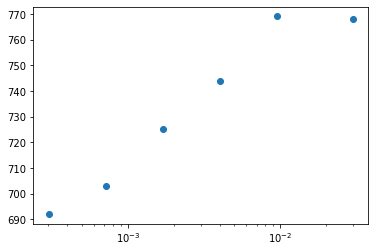

In [250]:
plt.scatter(total_affected.index,total_affected)
plt.xscale('log')

In [146]:
ejection_df

,0.000000e+00,1.970633e+03,2.985857e+03,2.997470e+03,3.981143e+03,3.992016e+03,4.998221e+03,4.999249e+03,5.911898e+03,5.988023e+03,...,2.089686e+06,2.100685e+06,2.132680e+06,2.153677e+06,2.203669e+06,2.301654e+06,2.382642e+06,2.424636e+06,2.509623e+06,2.520622e+06
0.030027,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750,0.64750
0.009496,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625,0.69625
0.004004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625,0.70625
0.001689,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875,0.84875
0.000712,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875,0.87875
0.000300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.92250,0.92375,0.92500,0.92625,0.92750,0.92875,0.93000,0.93125,0.93250,0.93375


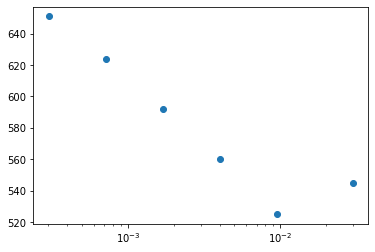

In [189]:
plt.scatter(total_affected.index,total_affected)
plt.xscale('log')

In [164]:
popt,pcov=curve_fit(log_fit,total_affected.index,total_affected)

In [166]:
popt[0]

-37.369197352278455

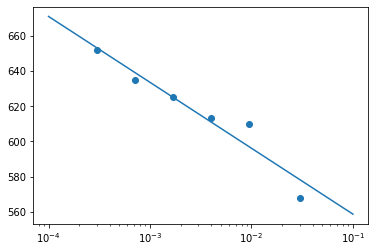

In [168]:
x=np.logspace(-4,-1,100)
y=log_fit(x,popt[0],popt[1])
plt.plot(x,y)
plt.scatter(total_affected.index,total_affected)
plt.xscale('log')

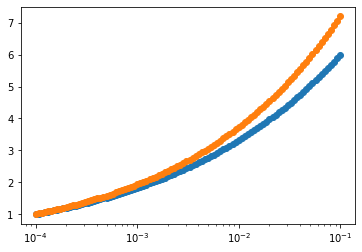

In [174]:
y2=y*x**(2/7)
y3=x**(2/7)
plt.scatter(x,y2/y2[0])
plt.scatter(x,y3/y3[0])
plt.xscale('log')

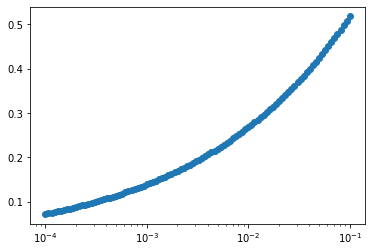

In [ ]:

plt.xscale('log')

In [12]:
def log_fit(q, a, b):
    return a * np.log10(q) + b

In [13]:
def e_frac_vs_mass(q):
    a=0.08509622694638502
    b=1.0913245932397357
    return a * np.log10(q) + b
def imf(Mstar):
    """Salpeter IMF, arbitrary normalization."""
    
    return 1000*Mstar**(-2.35)
def available_mass(M_star):
    """Moro_Martin 2018 Section 3.2.1"""
    return 1e-4*M_star

In [14]:
def integrated_ejection_mass(masses, e_frac=e_frac_vs_mass, imf=imf, planet_mass=0.000954588):
    weights=imf(masses)
    fractions=e_frac(planet_mass/masses)
    disc_mass=available_mass(masses)

    average_ejected_mass = np.trapz(weights * fractions * disc_mass, x=masses)/ np.trapz(weights, x=masses)
    return average_ejected_mass

In [492]:
integrated_ejection_mass(np.array([1,2,3]))

0.0001123298697901589

In [ ]:
masses = np.logspace(
    np.log10(0.2),
    np.log10(1.9),
    10000)

In [16]:
stellar_densities = np.array([
    0.08,
    6.0,
    326
])

# Planet masses [M_sun]
planet_masses = np.array([
    3.003e-6,      # Earth
    9.54588e-4,    # Jupiter
])

# Labels for table
planet_labels = [
    r"1 M_Earth",
    r"1 M_Jupiter"
]

table = pd.DataFrame(
    index=stellar_densities,
    columns=planet_labels,
    dtype=float
)

for density in stellar_densities:
    for planet_mass, label in zip(planet_masses, planet_labels):

        mass_per_star = integrated_ejection_mass(
            masses,
            planet_mass=planet_mass
        )

        table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"

table.index.name = "Stellar Density [stars / pc^3]"

table

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_49175/3147123783.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4774' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"
/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_49175/3147123783.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6380' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"


,1 M_Earth,1 M_Jupiter
Stellar Density [stars / pc^3],,
0.08,0.4774,0.6380
6.00,35.8041,47.8517
326.00,1945.3574,2599.9447


In [22]:
def a_distribution(a, C=350,beta=-0.86,a_0=3.6, gamma=1.59):
    prefactor=C*a**beta
    term_2=(1-np.exp(-(a/a_0)**gamma))
    return prefactor*term_2
def surface_density(a, r=-1):
    return a**r

    

In [24]:
def fulton_a(a, beta = -0.86,a0 = 3.6,gamma = 1.58):

    return (
        a**beta
        * (1 - np.exp(-(a / a0)**gamma))
    )
def log_normalized_fulton_a(
    beta=-0.86,
    a0=3.6,
    gamma=1.58,
    a_min=np.log10(0.03),
    a_max=np.log10(30)
):
    a = np.logspace(a_min, a_max, 1000)
    log_a = np.log10(a)

    fa = fulton_a(a)

    p_a = fa / np.trapz(fa, x=log_a)

    return a, p_a

In [30]:
a, p_a = log_normalized_fulton_a()

np.trapz(p_a, x=np.log10(a))

1.0

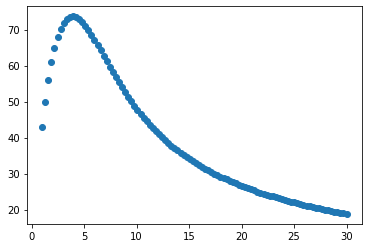

In [21]:
x=np.linspace(1,30,100)
y=a_distribution(x)
plt.scatter(x,y)

In [ ]:
def chaotic_zone_mass_fraction(
    Mstar,
    a_planet,
    planet_mass,
    surface_density=surface_density,
    r_disc_min=0.01,
    r_disc_max=30,
    n=1000,
):
    q = planet_mass / Mstar

    delta_a = 1.3 * q**(2/7) * a_planet

    mass_fraction=(2*delta_a)/(r_disc_max-r_disc_min)

    # cz_min = max(a_planet - delta_a, r_disc_min)
    # cz_max = min(a_planet + delta_a, r_disc_max)


    # # Mass in chaotic zone
    # r_cz = np.linspace(cz_min, cz_max, n)
    # sigma_cz = surface_density(r_cz, Mstar)

    # M_cz = np.trapz(
    #     2 * np.pi * r_cz * sigma_cz,
    #     x=r_cz
    # )

    # # Total disk mass represented by surface-density model
    # r_disc = np.linspace(r_disc_min, r_disc_max, n)
    # sigma_disc = surface_density(r_disc, Mstar)

    # M_disc = np.trapz(
    #     2 * np.pi * r_disc * sigma_disc,
    #     x=r_disc
    # )
    r_disc = np.linspace(r_disc_min, r_disc_max, n)
    np.trapz()

    return M_cz / M_disc

In [ ]:
# def average_chaotic_zone_fraction(m_star, planet_mass):
#     a, p_a = log_normalized_fulton_a()
#     q=planet_mass/m_star
#     cz_fractions = (
#     2 * 1.3 * q**(2/7) * a
#     / (r_disc_max - r_disc_min)
#     )

#     average_fraction = np.trapz(
#         p_a * cz_fractions,
#         x=np.log10(a)
#     )

#     return average_fraction

In [634]:
def average_chaotic_zone_fraction(m_star, planet_mass, a_min=0.03,a_max=30,r_disc_max = 50 ,r_disc_min=0.01, beta = -0.86,a0 = 3.6,gamma = 1.58):
    a = np.logspace(np.log10(a_min), np.log10(a_max), 1000)

    F = fulton_a(a, beta=beta, a0=a0, gamma=gamma)  # raw Fulton dN/dln(a)

    q = planet_mass / m_star

    cz_fractions = (
        2 * 1.3 * q**(2/7)
        / (r_disc_max - r_disc_min)
    )

    numerator = np.trapz(
        cz_fractions * F,
        x=a
    )

    denominator = np.trapz(
        F / a,
        x=a
    )

    return numerator / denominator

In [635]:

r_disc_max=100
a_max=r_disc_max/(1+1.3*0.001**(2/7))
r_disc_min=0.01
a_min=r_disc_min/(1-1.3*0.001**(2/7))
average_chaotic_zone_fraction(1.0,0.001,a_min=a_min,a_max=a_max,r_disc_max = r_disc_max ,r_disc_min=r_disc_min)

0.025809846960449558

Pieces I need: average_chaotic_zone_fraction(m_star,m_planet), imf(m_star), available_mass(m_star), ejection_function(m_planet,m_star),
johnson_occurence(m_star)

In [687]:
def e_frac_vs_mass(q):
    a=0.08509622694638502
    b=1.0913245932397357
    #return a * np.log10(q) + b
    return 1
def salpeter_imf(Mstar):
    """Salpeter IMF, arbitrary normalization."""
    
    return 1000*Mstar**(-2.35)


def kroupa_imf(m_star,alpha0 = 0.3,alpha1 = 1.3,alpha2 = 2.3, alpha3=2.3):
    """
    Kroupa (2001) IMF: dN/dM, up to an arbitrary normalization.

    """
    m = np.asarray(m_star, dtype=float)

    xi = np.zeros_like(m)

    # Kroupa slopes
    # alpha0 = 0.3
    # alpha1 = 1.3
    # alpha2 = 2.3

    # Continuity factors
    A0 = 1.0

    # Continuity at 0.08 Msun
    A1 = A0 * 0.08**(alpha1 - alpha0)

    # Continuity at 0.5 Msun
    A2 = A1 * 0.5**(alpha2 - alpha1)

    # Continuity at 1.0 Msun
    A3 = A2 * 1.0**(alpha3 - alpha2)

    mask0 = (m >= 0.01) & (m < 0.08)
    mask1 = (m >= 0.08) & (m < 0.5)
    mask2 = (m >= 0.5) & (m < 1.0)
    mask3 = m >= 1.0

    xi[mask0] = A0 * m[mask0]**(-alpha0)
    xi[mask1] = A1 * m[mask1]**(-alpha1)
    xi[mask2] = A2 * m[mask2]**(-alpha2)
    xi[mask3] = A3 * m[mask3]**(-alpha3)

    return xi

def imf(m_star, alpha_low=1.34, alpha_high=2.03, m_break=0.5):
    """
    Thin-disc IMF from Hallakoun & Maoz (2021).
    """
    m = np.asarray(m_star, dtype=float)

    # Arbitrary normalization for low-mass branch
    A_low = 1.0

    # Ensure continuity at the break
    A_high = A_low * m_break**(alpha_high - alpha_low)

    return np.where(
        m < m_break,
        A_low * m**(-alpha_low),
        A_high * m**(-alpha_high)
    )
def available_mass(M_star):
    """Moro_Martin 2018 Section 3.2.1"""
    return 1e-4*M_star

In [688]:
def johnson_occurrence(m_star, feh=0.0, C=0.07, alpha=1.0):
    """VALID FOR 0.2-1.9 SOLAR MASSES"""
    return C * m_star**alpha * 10**(1.2 * feh)
def planet_mass_distribution(m_planet): #PLACEHOLDER
    return np.ones_like(m_planet, dtype=float)

In [689]:
def fulton_a(a, beta = -0.86,a0 = 3.6,gamma = 1.58):

    return (
        a**beta
        * (1 - np.exp(-(a / a0)**gamma))
    )

In [690]:
def integrated_ejected_mass(
    m_star_min=0.2,
    m_star_max=1.9,
    m_planet_min=1e-5,
    m_planet_max=1e-2,
    n_star=1000,
    n_planet=1000,
    johnson_C=0.07,
    johnson_alpha=1.0,
    fulton_beta=-0.86,
    fulton_a0=3.6,
    fulton_gamma=1.58,
    kroupa_alpha0 = 0.3,
    kroupa_alpha1 = 1.3,
    kroupa_alpha2 = 2.3,
    kroupa_alpha3=2.3,
    HM_alpha_low=1.34,
    HM_alpha_high=2.03
):
    m_stars = np.logspace(
        np.log10(m_star_min),
        np.log10(m_star_max),
        n_star
    )

    m_planets = np.logspace(
        np.log10(m_planet_min),
        np.log10(m_planet_max),
        n_planet
    )

    ln_m_planets = np.log(m_planets)

    # Planet-mass PDF assumed to be per d ln(Mp)
    p_planet = planet_mass_distribution(m_planets)

    # Normalize planet-mass PDF
    p_planet /= np.trapz(p_planet, x=ln_m_planets)


    result_vs_star = np.zeros_like(m_stars)

    for i, m_star in enumerate(m_stars):

        planet_integrand=(
            p_planet*
            average_chaotic_zone_fraction(m_star,m_planets, beta=fulton_beta, a0=fulton_a0, gamma=fulton_gamma)*
            e_frac_vs_mass(m_planets/m_star)
        )


        planet_average=np.trapz(
            planet_integrand,
            x=ln_m_planets 
        )

        result_vs_star[i] = (
            imf(m_star,alpha_low=HM_alpha_low, alpha_high=HM_alpha_high)*
            johnson_occurrence(m_star, C=johnson_C, alpha=johnson_alpha)*
            available_mass(m_star)*
            planet_average*333030
        )
        #print(planet_average)

    numerator=np.trapz(result_vs_star, x=m_stars)

    denominator = np.trapz(imf(m_stars), x=m_stars)
        #denominator=1

    return numerator/denominator


In [691]:
average_chaotic_zone_fraction(1.0,1e-5)

0.009576341276576663

In [692]:
print(integrated_ejected_mass(0.2,1.9, 1e-5,1e-2))

0.052941878551572875


In [693]:
params = {
    "C": 0.07,
    "alpha": 1.0,
    "beta" : -0.86,
    "a0" : 3.6,
    'gamma' : 1.58
}
print(params["C"])

0.07


In [694]:
def derivative_param(func, params, key, step, step_plus=None, step_minus=None):
    p_plus = params.copy()
    p_minus = params.copy()

    if step_plus:
        p_plus[key] += step_plus
        p_minus[key] -= step_minus
    else:
        p_plus[key] += step
        p_minus[key] -= step

    return (
        func(**p_plus) - func(**p_minus)
    ) / (2 * step)

In [695]:
for key in params.keys():
    print(key)

C
alpha
beta
a0
gamma


NEXT 3:

In [696]:
param_info = {
    "johnson_C":     (0.07, 0.01, 0.01),
    "johnson_alpha": (1.0,  0.3,  0.3),
    "fulton_beta":   (-0.86, 0.41, 0.20),
    "fulton_a0":     (3.6,  2.0,  1.8),
    "fulton_gamma":  (1.58, 0.36, 0.33),
    "kroupa_alpha0": (0.3, 0.7, 0.7),
    "kroupa_alpha1": (1.3, 0.5, 0.5),
    "kroupa_alpha2": (2.3, 0.3, 0.3),
    "kroupa_alpha3": (2.3, 0.7, 0.7),
    "HM_alpha_low": (1.34, 0.11,0.22),
    "HM_alpha_high": (2.03, 0.14, 0.05)
}

In [697]:
def derivative_param(func, param_info, key, step):

    # Extract central values
    params = {
        name: values[0]
        for name, values in param_info.items()
    }

    p_plus = params.copy()
    p_minus = params.copy()

    p_plus[key] += step
    p_minus[key] -= step

    return (
        func(**p_plus) - func(**p_minus)
    ) / (2 * step)

In [716]:

R = integrated_ejected_mass(
    **{
        name: values[0]
        for name, values in param_info.items()
    }
)

lower_variance = 0.0
upper_variance = 0.0

for param_name, (value, sigma_minus, sigma_plus) in param_info.items():

    deriv = derivative_param(
        integrated_ejected_mass,
        param_info,
        param_name,
        step=1e-4
    )

    if deriv >= 0:
        delta_R_minus = abs(deriv) * sigma_minus
        delta_R_plus  = abs(deriv) * sigma_plus
    else:
        delta_R_minus = abs(deriv) * sigma_plus
        delta_R_plus  = abs(deriv) * sigma_minus

    lower_variance += delta_R_minus**2
    upper_variance += delta_R_plus**2

sigma_R_minus = np.sqrt(lower_variance)
sigma_R_plus  = np.sqrt(upper_variance)

print(f"R = {R} -{sigma_R_minus} +{sigma_R_plus}")

R = 0.052941878551572875 -0.04134277686376387 +0.029678722894016674


In [ ]:
R = integrated_ejected_mass(**params)

lower_variance = 0.0
upper_variance = 0.0

for param_name, (sigma_minus, sigma_plus) in sigmas.items():

    deriv = derivative_param(
        integrated_ejected_mass,
        params,
        param_name,
        step=1e-4
    )

    if deriv >= 0:
        lower_contribution = abs(deriv) * sigma_minus
        upper_contribution = abs(deriv) * sigma_plus
    else:
        # Increasing the parameter decreases R,
        # so parameter +/- maps to result -/+
        lower_contribution = abs(deriv) * sigma_plus
        upper_contribution = abs(deriv) * sigma_minus

    lower_variance += lower_contribution**2
    upper_variance += upper_contribution**2

sigma_R_minus = np.sqrt(lower_variance)
sigma_R_plus  = np.sqrt(upper_variance)

print(
    f"R = {R:.4g} "
    f"-{sigma_R_minus:.2g} "
    f"+{sigma_R_plus:.2g}"
)

In [ ]:
params = {
    "johnson_C": 0.07,
    "johnson_alpha": 1.0,
    "fulton_beta" : -0.86,
    "fulton_a0" : 3.6,
    'fulton_gamma' : 1.58
}

sigmas = {
    'sigma_C':[0.01, 0.01],
    'sigma_alpha':[0.3, 0.3],
    'sigma_beta':[0.41,0.41]
}
# sigma_C=0.01
# sigma_alpha=0.3
# sigma_beta=-0.41



R = integrated_ejected_mass(**params)
derivative_list=[]

for param_name in params.keys():
    dR_dparam =  derivative_param(
    integrated_ejected_mass,
    params,
    param_name,
    step=1e-4
    )

    derivative_list.append(dR_dparam)

for deriv, sigma in zip(derivative_list, sigmas.keys()):



dR_dC = derivative_param(
    integrated_ejected_mass,
    params,
    "johnson_C",
    step=1e-4
)

dR_dalpha = derivative_param(
    integrated_ejected_mass,
    params,
    "johnson_alpha",
    step=1e-4
)

dR_dbeta = derivative_param(
    integrated_ejected_mass,
    params,
    "fulton_beta",
    step=1e-4
)



sigma_R_C = abs(dR_dC) * sigma_C
sigma_R_alpha = abs(dR_dalpha) * sigma_alpha
sigma_R_beta = abs

sigma_R = np.sqrt(
    sigma_R_C**2
    + sigma_R_alpha**2
)

print("Result:", R)
print("Johnson uncertainty:", sigma_R)

Result: 0.03625835316896766
Johnson uncertainty: 0.006312107898993077


In [ ]:
def compute_parameter_uncertainties(params, sigmas):
    for param, sigma in zip(param)

In [527]:
a_max

84.7002245499997

In [94]:
average_chaotic_zone_fraction(1, 0.001)

0.03613957411067788